In [1]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
import pickle
import mlflow
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope 

/usr/local/python/3.12.1/lib/python3.12/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Need to set tracking URI bc we are running mlflow with sqlite backend
mlflow.set_tracking_uri('sqlite:///mlflow.db')
# It will check whether this name exists. If the experiment name does not exist, then it will create a new experiment with this name and assign all runs to this experiment. 
mlflow.set_experiment('Module2')

2025/06/29 05:37:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/06/29 05:37:37 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


<Experiment: artifact_location='/workspaces/MLOps_Zoomcamp/02-Experiment_Tracking/mlruns/1', creation_time=1750554429050, experiment_id='1', last_update_time=1750554429050, lifecycle_stage='active', name='Module2', tags={}>

In [ ]:
!pip install pyarrow

In [3]:
df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2024-01.parquet')

In [4]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2024-01-01 00:46:55,2024-01-01 00:58:25,N,1.0,236,239,1.0,1.98,12.8,1.0,0.5,3.61,0.0,NaN,1.0,21.66,1.0,1.0,2.75
1,2,2024-01-01 00:31:42,2024-01-01 00:52:34,N,1.0,65,170,5.0,6.54,30.3,1.0,0.5,7.11,0.0,NaN,1.0,42.66,1.0,1.0,2.75
2,2,2024-01-01 00:30:21,2024-01-01 00:49:23,N,1.0,74,262,1.0,3.08,19.8,1.0,0.5,3.00,0.0,NaN,1.0,28.05,1.0,1.0,2.75
3,1,2024-01-01 00:30:20,2024-01-01 00:42:12,N,1.0,74,116,1.0,2.40,14.2,1.0,1.5,0.00,0.0,NaN,1.0,16.70,2.0,1.0,0.00
4,2,2024-01-01 00:32:38,2024-01-01 00:43:37,N,1.0,74,243,1.0,5.14,22.6,1.0,0.5,6.28,0.0,NaN,1.0,31.38,1.0,1.0,0.00


In [5]:
# Originally wanted only dispatch type but this trip-type resulted in a lot of data that were less than one minute
# df = df[df.trip_type == 2] # filters out all data for only dispatch trip types (which is trip_type = 2)

In [6]:
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime

In [7]:
df['duration'] = df['duration']/pd.Timedelta(minutes=1)

[]

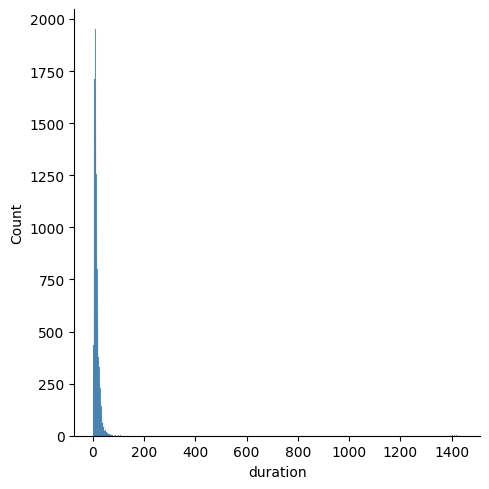

In [8]:
sns.displot(df.duration)
plt.plot()
# The distribution has a very long tail, so we cannot see the distribution well.

In [9]:
# Used describe to better understand the statistics/distribution
df.duration.describe()

count    56551.000000
mean        18.171379
std         75.464751
min          0.000000
25%          7.250000
50%         11.400000
75%         17.316667
max       1438.983333
Name: duration, dtype: float64

In [10]:
# These trip times look suspicious. To get a closer look, we specify some percentiles to look at
df.duration.describe(percentiles=[0.95, 0.98, 0.99])

count    56551.000000
mean        18.171379
std         75.464751
min          0.000000
50%         11.400000
95%         33.683333
98%         46.816667
99%         59.825000
max       1438.983333
Name: duration, dtype: float64

In [11]:
# These trip times look suspicious. To get a closer look, we specify some percentiles to look at
df.duration.describe(percentiles=[0.95, 0.98, 0.99])
# From business perspective, we only want to look at rides one hour or less. 
# Filtering out all rides over an hour or less than one minute
df = df[(df.duration <= 60.0) & (df.duration >= 1.0)]
print(df.duration.describe())

count    54373.000000
mean        13.778175
std          9.021503
min          1.000000
25%          7.583333
50%         11.566667
75%         17.300000
max         60.000000
Name: duration, dtype: float64


In [12]:
# We need to think about what categorical and what numerical variables we will use
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']
df[categorical].dtypes # Understanding the data types for the categorical

PULocationID    int32
DOLocationID    int32
dtype: object

In [13]:
# Change data types for categorical since it is currently integers
df[categorical] = df[categorical].astype(str)
train_dicts = df[categorical + numerical].to_dict(orient='records') # turns each row into a dictionary
# Now we vectorize our dictionaries, bc we want to create one hot encoding using dictvectorizer
dv = DictVectorizer() # create object (instance) of DictVectorizer

In [14]:
# Now, we create our feature matrix (X_train) and our target matrix (Y_train).
X_train = dv.fit_transform(train_dicts) # create our feature matrix for training
print(X_train)
Y_train = df['duration'].values # The Y values are just the duration values. These are our target values.
print(Y_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 163119 stored elements and shape (54373, 449)>
  Coords	Values
  (0, 139)	1.0
  (0, 357)	1.0
  (0, 448)	1.98
  (1, 70)	1.0
  (1, 416)	1.0
  (1, 448)	6.54
  (2, 163)	1.0
  (2, 425)	1.0
  (2, 448)	3.08
  (3, 12)	1.0
  (3, 425)	1.0
  (3, 448)	2.4
  (4, 144)	1.0
  (4, 425)	1.0
  (4, 448)	5.14
  (5, 106)	1.0
  (5, 389)	1.0
  (5, 448)	2.0
  (6, 138)	1.0
  (6, 425)	1.0
  (6, 448)	3.2
  (7, 139)	1.0
  (7, 293)	1.0
  (7, 448)	2.01
  (8, 125)	1.0
  :	:
  (54364, 448)	1.6
  (54365, 51)	1.0
  (54365, 293)	1.0
  (54365, 448)	1.09
  (54366, 45)	1.0
  (54366, 318)	1.0
  (54366, 448)	1.52
  (54367, 137)	1.0
  (54367, 397)	1.0
  (54367, 448)	2.75
  (54368, 150)	1.0
  (54368, 389)	1.0
  (54368, 448)	0.0
  (54369, 213)	1.0
  (54369, 423)	1.0
  (54369, 448)	0.49
  (54370, 213)	1.0
  (54370, 423)	1.0
  (54370, 448)	0.52
  (54371, 183)	1.0
  (54371, 397)	1.0
  (54371, 448)	1.17
  (54372, 233)	1.0
  (54372, 389)	1.0
  (54372, 448)	9.27
[11.5      

In [15]:
dv.feature_names_ # feature names the vectorizer uses. Each feature is one hot encoded.

['DOLocationID=1',
 'DOLocationID=10',
 'DOLocationID=100',
 'DOLocationID=101',
 'DOLocationID=102',
 'DOLocationID=106',
 'DOLocationID=107',
 'DOLocationID=108',
 'DOLocationID=11',
 'DOLocationID=112',
 'DOLocationID=113',
 'DOLocationID=114',
 'DOLocationID=116',
 'DOLocationID=117',
 'DOLocationID=118',
 'DOLocationID=119',
 'DOLocationID=12',
 'DOLocationID=120',
 'DOLocationID=121',
 'DOLocationID=122',
 'DOLocationID=123',
 'DOLocationID=124',
 'DOLocationID=125',
 'DOLocationID=126',
 'DOLocationID=127',
 'DOLocationID=128',
 'DOLocationID=129',
 'DOLocationID=13',
 'DOLocationID=130',
 'DOLocationID=131',
 'DOLocationID=132',
 'DOLocationID=133',
 'DOLocationID=134',
 'DOLocationID=135',
 'DOLocationID=136',
 'DOLocationID=137',
 'DOLocationID=138',
 'DOLocationID=139',
 'DOLocationID=14',
 'DOLocationID=140',
 'DOLocationID=141',
 'DOLocationID=142',
 'DOLocationID=143',
 'DOLocationID=144',
 'DOLocationID=145',
 'DOLocationID=146',
 'DOLocationID=147',
 'DOLocationID=148',

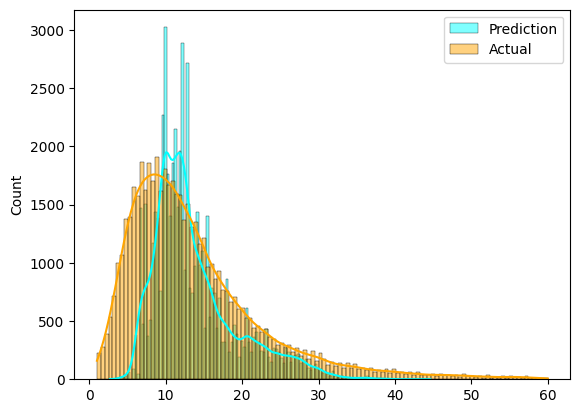

In [16]:
# Now we train a model (linear regression model)
lr = LinearRegression()
lr.fit(X_train, Y_train)
# Now that we fitted the data to our model, we will apply the model onto our training dataset (just to see its current performance)
# (We will use the February dataset as the validation dataset later)
Y_pred = lr.predict(X_train)
# These functions are figure-level functions so they will create separate figures.
# sns.displot(Y_pred, label='prediction')
# sns.displot(Y_train, label='training')
# To create overlaid plots in the same figure, we need an axes-level figure:
sns.histplot(Y_pred, color="cyan", label="Prediction", kde=True) # kde = kernel density estimation. This curve estimates the distribution
sns.histplot(Y_train, color="orange", label="Actual", kde=True)
# KDE is a non-parametric way to estimate the probability density function (PDF) of a continuous variable. 
# In simpler terms, it gives you a smooth curve that represents the distribution of your data.
plt.legend()

In [17]:
# Estimate the score, we use RMSE
rmse = root_mean_squared_error(Y_train, Y_pred)
print(rmse) # 7 min, therefore our model is wrong on average by 7 min.

7.1228220948023795


In [18]:
# Now, we want to see the results on the validation dataset

df_val = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2024-02.parquet')
df_val['duration'] = df_val.lpep_dropoff_datetime - df_val.lpep_pickup_datetime
df_val['duration'] = df_val['duration']/pd.Timedelta(minutes=1)
df_val = df_val[(df_val.duration <= 60.0) & (df_val.duration >= 1.0)]
df_val[categorical] = df_val[categorical].astype(str)

len(df), len(df_val) # we want to see the split
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)
Y_val = df_val['duration'].values

Y_pred_val = lr.predict(X_val)
rmse_val = root_mean_squared_error(Y_val, Y_pred_val)
print(rmse_val) # Trying the model on the validation got us 7.3 min, slightly worse. This is our baseline since we want to predict validation, not training dataset.

7.265831283470444


In [19]:
# Start a run
with mlflow.start_run():
    # Logging info about this current run. Set tag for better filtering. 
    mlflow.set_tag("Developer", "Kevin")
    # Now logging info about dataset (simplified logging, not perfect).
    mlflow.log_param("train-data-path", "./data/green_tripdata_2021-01.parquet") 
    mlflow.log_param("valid-data-path", "•/data/green_tripdata_2021-02.parquet")
    alpha = 0.01
    # Log alpha value: needs to be key-value pair. What are we logging and what is the value.
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha )
    lr.fit(X_train, Y_train)
    Y_pred_lass = lr.predict(X_val)
    rmse = root_mean_squared_error(Y_val, Y_pred_lass)
    # Want to track our results, so log RMSE 
    mlflow.log_metric("rmse", rmse)
    # If training the model across epochs, can essentially get the learning curve across time
    mlflow.log_artifact(local_path='models/lin_reg.bin', artifact_path='models_pickle') 
    print(mlflow.get_tracking_uri())  # Should be 'sqlite:///mlflow.db'

sqlite:///mlflow.db


In [20]:
# Second way of logging model with mlflow (This is a second, alternative run)

train = xgb.DMatrix(X_train, label=Y_train) # Provide training dataset and the labels (target values)
valid = xgb.DMatrix(X_val, label=Y_val) # Provide validation dataset and labels (target values)
mlflow.end_run()
with mlflow.start_run():
    best_params = {
        'learning_rate': 0.09585355369315604,
        'max_depth': 30,
        'min_child_weight': 1.060597050922164,
        'objective': 'reg:linear',
        'reg_alpha': 0.018060244040060163,
        'reg_lambda': 0.011658731377413597,
        'seed': 42
    }
    
    mlflow.log_params(best_params)
    
    booster = xgb.train(
        params=best_params, 
        dtrain=train, 
        num_boost_round=1000,
        evals=[(valid, 'validation' )], 
        early_stopping_rounds=50
    )
    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(Y_val, Y_pred_lass)
    mlflow.log_metric("rmse", rmse)
    # Need to log the preprocessor (the preprocessed data). 
    # Therefore, we will pickle and save dict vectorizer as preprocessor and pass the path to be saved as an artifact in mlflow.
    with open('models/preprocessor.b ', 'wb') as f_out:
        pickle.dump(dv, f_out) #  pickle.dump(what we are saving), where we are saving it to)
    mlflow.log_artifact('models/preprocessor.b', artifact_path='preprocessor') #b=binary
    mlflow.xgboost.log_model(booster, artifact_path='models_mlflow') 

/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [05:37:52] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[0]	validation-rmse:8.52972
[1]	validation-rmse:8.02187
[2]	validation-rmse:7.58510
[3]	validation-rmse:7.20782
[4]	validation-rmse:6.88614
[5]	validation-rmse:6.60773
[6]	validation-rmse:6.37581
[7]	validation-rmse:6.17963
[8]	validation-rmse:6.01001
[9]	validation-rmse:5.87106
[10]	validation-rmse:5.74907
[11]	validation-rmse:5.64861
[12]	validation-rmse:5.56926
[13]	validation-rmse:5.49985
[14]	validation-rmse:5.44123
[15]	validation-rmse:5.39558
[16]	validation-rmse:5.35880
[17]	validation-rmse:5.32704
[18]	validation-rmse:5.29936
[19]	validation-rmse:5.27658
[20]	validation-rmse:5.25818
[21]	validation-rmse:5.24016
[22]	validation-rmse:5.22777
[23]	validation-rmse:5.21683
[24]	validation-rmse:5.20633
[25]	validation-rmse:5.19945
[26]	validation-rmse:5.19413
[27]	validation-rmse:5.18916
[28]	validation-rmse:5.18444
[29]	validation-rmse:5.18058
[30]	validation-rmse:5.17732
[31]	validation-rmse:5.17373
[32]	validation-rmse:5.17040
[33]	validation-rmse:5.16747
[34]	validation-rmse:5.1

2025/06/29 05:38:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/xgboost/__init__.py:168: UserWarning: [05:38:08] WARNING: /workspace/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  xgb_model.save_model(model_data_path)
2025/06/29 05:38:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [21]:
# We'll try using another model instead: XGBoost (Extreme Gradient Boosting).
# Use hyperopt to optimize the hyperparameters of this model and log all of this into mlflow.
import xgboost as xgb
# hyperopt = library using bayesian methods to find best set of hyperparameters.
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
# fmin minimizes object function. Essentially, minimizes the output of a function (models are just functions). 
# To use fmin, need to pass a set of values that the library will use to try to find the min output.
# Tpe = algorithm used to control the logic for fmin. 
# hp = library with methods to define the search space (ie ranges of each hyperparameter we will use.
# STATUS_OK = signal sent at end of each run to tell hyperopt that the objective function has run successfully. 
# Trials = keeps track of info from each run.
from hyperopt.pyll import scope 
# scope used to define range of type integer. 

In [22]:
# XGBoost requires certain data types for training and validation datasets. We will create them now.
train = xgb.DMatrix(X_train, label=Y_train) # Provide training dataset and the labels (target values)
valid = xgb.DMatrix(X_val, label=Y_val) # Provide validation dataset and labels (target values)

In [23]:
# First step is to define the objective function

# X_Val and Y_Val come from df_val (Feb) dataset. X_train and Y_train comes from df (Jan) dataset.
# Therefore, rmse needs to use y_pred instead of Y_pred
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "XGBoost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain= train, # XGBoost requires specific data type for training data set.
            num_boost_round=1000,
            evals=[(valid, "validation")], # XGBoost requires specific data type for validation data set.
            early_stopping_rounds=50
        )
        y_pred=booster.predict(valid)
        rmse = root_mean_squared_error(Y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}
    
# XGBoost takes in hyperparameter params. We train XGBoost using params on the training dataset dtrain. 
# the validation set in evals is used to control the optimization (XGBoost minimizes the error in the validation set).
# There is a maximum of 1000 iterations of the booster set for XGBoost. 
# If there are 50 or more iterations without improvement on the validation error, then XGBoost will stop. 
# Once the model is trained, we make prediction on the validation set (calculating the target for the validation set). RMSE used to find error. 

In [24]:
# Next, we need to define the search space
# search space = ranges we want hyperopt to explore the hyperparameters
# hyperparameters for XGBoost are: max depth, learning rate, reg alpha, reg lambda, min child weight, seed
search_space = {
'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
'learning_rate': hp.loguniform('learning_rate', -3, 0),
'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
'objective': 'reg:linear',
'seed': 42,
}
# max depth controls the depths of the trees. quniform investigates the depth from 4-100 levels (ranges we want to explore these parameters). quniform returns float, so we want to turn it into int for max depth. 
# quniform: rounding the sampling of a uniform distribution between low and high and dividing by q and then multiplies the whole thing by q.
# loguniform: drawing values from this distribution exp(uniform(low, high)). Basically means variable will be constrained to interval [exp(low), exp(high)].
# Define learning rate from loguniform space from -3 to 0.

In [30]:
# After we define objective function and search space, we can input these into the fmin function.
best_result = fmin(
    fn=objective,
    space=search_space, 
    algo=tpe.suggest,
    max_evals=50, 
    trials=Trials())
# optimize fn (objective function) by minimizing output. # of iteration = 50, algorithm = tpe, need to pass objective Trials (this is where all info from each run will be stored). 


[0]	validation-rmse:5.37911                                                                                                                                                                                               
  0%|                                                                                                                                                                              | 0/50 [00:00<?, ?trial/s, best loss=?]

/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [23:16:44] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[1]	validation-rmse:5.24305                                                                                                                                                                                               
[2]	validation-rmse:5.23273                                                                                                                                                                                               
[3]	validation-rmse:5.21766                                                                                                                                                                                               
[4]	validation-rmse:5.20906                                                                                                                                                                                               
[5]	validation-rmse:5.21795                                                                                                 

/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [23:16:49] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:8.03871                                                                                                                                                                                               
[1]	validation-rmse:7.24506                                                                                                                                                                                               
[2]	validation-rmse:6.66339                                                                                                                                                                                               
[3]	validation-rmse:6.24580                                                                                                                                                                                               
[4]	validation-rmse:5.94852                                                                                                 

...

/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [23:19:18] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:5.46165                                                                                                                                                                                               
[1]	validation-rmse:5.40836                                                                                                                                                                                               
[2]	validation-rmse:5.40495                                                                                                                                                                                               
[3]	validation-rmse:5.42178                                                                                                                                                                                               
[4]	validation-rmse:5.43811                                                                                                 

/usr/local/python/3.12.1/lib/python3.12/site-packages/xgboost/callback.py:386: UserWarning: [23:19:22] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[1]	validation-rmse:8.08259                                                                                                                                                                                               
[2]	validation-rmse:7.66349                                                                                                                                                                                               
[3]	validation-rmse:7.29740                                                                                                                                                                                               
[4]	validation-rmse:6.98128                                                                                                                                                                                               
[5]	validation-rmse:6.70777                                                                                                 

KeyboardInterrupt: 

In [25]:
# Loading a model as a python function using Spark
logged_model = 'runs:/088f9cd07a9f49f6b23b141076902c53/models_mlflow'
# Load model as a Spark UDF. Override result_type if the model does not return double values.
loaded_model = mlflow.pyfunc.spark_udil(spark, model_uri=logged_model, result_type='double')
# Predict on a Spark DataFrame.
columns = list(df.columns)
df.withColumn('predictions', loaded_model(*columns)).collect()

AttributeError: module 'mlflow.pyfunc' has no attribute 'spark_udil'

In [26]:
# Loading a model as a python function using Pandas
logged_model = 'runs:/088f9cd07a9f49f6b23b141076902c53/models_mlflow'
# Load model as a PyFuncModel.
loaded_model = mlflow.pyfunc.load_model(logged_model)
# Predict on a Pandas DataFrame.
# loaded_model.predict(pd.DataFrame(data))
loaded_model # The model returns an object of mlflow.pyfunc.loaded_model because it is a python function and created a python object.

mlflow.pyfunc.loaded_model:
  artifact_path: /workspaces/MLOps_Zoomcamp/02-Experiment_Tracking/mlruns/1/models/m-4e8c69c68b194b848752782e4dc40e15/artifacts
  flavor: mlflow.xgboost
  run_id: 088f9cd07a9f49f6b23b141076902c53

In [27]:
# Loading the model as an XGBoost model (XGBoost flavor)
xgboost_model = mlflow.xgboost.load_model('runs:/088f9cd07a9f49f6b23b141076902c53/models_mlflow')
xgboost_model # the model returns an xgboost type object.

In [28]:
# Now we can make predictions with this loaded model
y_pred = xgboost_model.predict(valid)
# Now we just see the first 10 elements to see if it matches the same results as before (it should)
y_pred[:10]

array([19.519665 , 35.52862  ,  9.49126  ,  8.360411 ,  3.5231287,
        4.2043934, 10.682295 , 15.288675 , 23.178114 ,  6.4996505],
      dtype=float32)

In [29]:
# Since Lasso did not improve the error, we will try ridge
rid = Ridge()
rid.fit(X_train, Y_train)
Y_pred_lass = rid.predict(X_val)
root_mean_squared_error(Y_val, Y_pred_lass) # Our error is even worse, so we need to tweak the lasso model a bit.

7.263147327402421

In [20]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out) #  pickle.dump(what we are saving), where we are saving it to)

# Notes:
- Tracking experiments: can make a notes cell to track outputs from experiments or track in a spreadsheet. A better way is to use log. (log to experiment tracker).
- Saving models: instead of saving the model using pickle (we don't know which lr was last run, we don't know the performance of the model, we might not remember which linear regression model we used since name is just lin_reg). INSTEAD, we should save to model registry.
- Experiment tracker + model registry allows for models with performance to be saved so no ambiguity.
- MLFlow is used for these purposes.
- ML Pipelines: best practices/tools so we don't need to worry about which cells need to be run and in what order and what does not need to be run (Prefect and Kubeflow are tools for ML pipelines).

# Notes: MLOps Maturity Levels (Microsoft definition)
- MLOps maturity levels (0-4): At the highest maturity level, fully automated. The system can retrain the model by itself when performance drops.
- 0: No MLOps: Jupyter notebooks, no proper experimental methods, no metadata, no pipelines, no automation
- 1: DevOps, no MLOps. Some automation, releases automated. unit and integration tests, CI/CD, Operational metrics (requests/sec, network situation, etc.). No experiment tracking, no reproducibility, DS separated from engineers.
- 2: Automated Training: Training Pipeline (parametrized pipelines), Experiment tracking, Model registry (know which models are in production and which are not), low friction deployment (easy but not necessarily automated), DS work with engineers
- 3: Automated deployment: Easy to deploy model (either automated or low friction), have ML platform (place for hosting models) - can deploy model with simple API call, run A/B tests, model monitoring
- 4: Full MLOps Automation - automatic training, automatic retraining, automatic deployment.